## Group 3
* Daniel Winston Mandela Tulung - 23/516260/PA/22080
* Girindra Daafi Mada - 23/511637/PA/21835
* Keefani Mentari Ingprairie - 23/511420/PA/21792
* Naura Ayesha Tsaqif - 23/511457/PA/21800

Dataset: https://www.kaggle.com/datasets/alik05/forest-fire-dataset


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alik05/forest-fire-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1


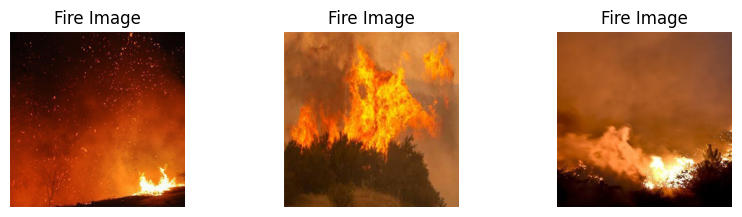

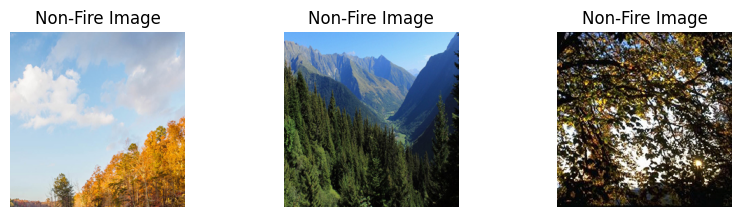

In [2]:
import random
import os
import cv2

# Set paths for fire and non-fire images
fire_path = '/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Training/fire'
non_fire_path = '/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Training/nofire'

import matplotlib.pyplot as plt

def show_random_images(image_paths, title):
    plt.figure(figsize=(10, 5))
    for i, img_path in enumerate(random.sample(image_paths, 3)):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.show()

fire_images = [os.path.join(fire_path, img) for img in os.listdir(fire_path)]
non_fire_images = [os.path.join(non_fire_path, img) for img in os.listdir(non_fire_path)]

show_random_images(fire_images, 'Fire Image')
show_random_images(non_fire_images, 'Non-Fire Image')

In [3]:
print(f"Number of fire images: {len(fire_images)}")
print(f"Number of non-fire images: {len(non_fire_images)}")

Number of fire images: 760
Number of non-fire images: 760


In [4]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import local_binary_pattern

def contrast_stretching(image):
    # Apply contrast stretching to an image (or a single channel)
    min_val = np.min(image)
    max_val = np.max(image)

    # Stretching the contrast to the range 0-255
    stretched_image = ((image - min_val) / (max_val - min_val)) * 255
    return stretched_image.astype(np.uint8)

def detect_forest_fire_and_extract_features(image_path):
    image = cv2.imread(image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Apply contrast stretching to the V channel (brightness)
    hsv_image[:, :, 2] = contrast_stretching(hsv_image[:, :, 2])

    # Refined HSV range for fire colors
    lower_fire = np.array([10, 100, 100])  # Adjusted to focus more on fire colors
    upper_fire = np.array([20, 255, 255])  # Adjusted upper bound for more accuracy
    fire_mask = cv2.inRange(hsv_image, lower_fire, upper_fire)

    # Otsu filtering for fire regions
    v_channel = hsv_image[:, :, 2]
    _, otsu_thresholded = cv2.threshold(v_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    fire_mask = cv2.bitwise_and(fire_mask, otsu_thresholded)

    # Edge detection to refine fire mask
    sobel_x = cv2.Sobel(v_channel, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(v_channel, cv2.CV_64F, 0, 1, ksize=3)
    edges = cv2.magnitude(sobel_x, sobel_y).astype(np.uint8)
    fire_mask = cv2.bitwise_and(fire_mask, edges)

    # Morphological operations
    kernel = np.ones((5, 5), np.uint8)  # Slightly larger kernel to close gaps
    fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_CLOSE, kernel)
    fire_mask = cv2.erode(fire_mask, kernel, iterations=1)

    # Contour detection for fire regions
    contours, _ = cv2.findContours(fire_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    fire_regions = []
    features = []  # List to store features
    for contour in contours:
        # Filter based on contour area and shape
        if cv2.contourArea(contour) > 200:  # Increased the area threshold
            # Check aspect ratio of bounding boxes
            x, y, w, h = cv2.boundingRect(contour)
            aspect_ratio = w / float(h)
            if 0.5 < aspect_ratio < 2:  # Keep reasonable aspect ratio (fire-like shapes)
                fire_regions.append(contour)

                # Extract features
                area = cv2.contourArea(contour)
                perimeter = cv2.arcLength(contour, True)
                extent = area / (w * h)
                circularity = (4 * np.pi * area) / (perimeter ** 2)

                # Create mask for region and calculate mean HSV values
                mask = np.zeros_like(fire_mask)
                cv2.drawContours(mask, [contour], -1, 255, -1)
                mean_hsv = cv2.mean(hsv_image, mask=mask)[:3]

                # Edge density
                edge_density = np.sum(edges & mask) / np.sum(mask)

                # Gradient statistics
                grad_x_mean = np.mean(sobel_x[mask > 0])
                grad_x_std = np.std(sobel_x[mask > 0])
                grad_y_mean = np.mean(sobel_y[mask > 0])
                grad_y_std = np.std(sobel_y[mask > 0])

                # Texture analysis: Local Binary Patterns (LBP)
                lbp = local_binary_pattern(cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), 8, 1, method='uniform')
                lbp_mean = np.mean(lbp[mask > 0])
                lbp_std = np.std(lbp[mask > 0])

                # Add features to the list
                feature_vector = [
                    area, perimeter, aspect_ratio, extent, circularity,
                    *mean_hsv, edge_density, grad_x_mean, grad_x_std, grad_y_mean, grad_y_std,
                    lbp_mean, lbp_std
                ]
                features.append(feature_vector)

    # Draw bounding boxes on detected fire regions
    output_image = image.copy()
    for contour in fire_regions:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # Save features to CSV
    feature_columns = [
        "Area", "Perimeter", "Aspect_Ratio", "Extent", "Circularity",
        "Mean_H", "Mean_S", "Mean_V", "Edge_Density",
        "Grad_X_Mean", "Grad_X_Std", "Grad_Y_Mean", "Grad_Y_Std",
        "LBP_Mean", "LBP_Std"
    ]
    features_df = pd.DataFrame(features, columns=feature_columns)
    features_df.to_csv("fire_features.csv", index=False)

    return output_image, features_df


In [5]:
# Load images and features
def load_images_and_features(fire_path, non_fire_path):
    fire_images = [os.path.join(fire_path, img) for img in os.listdir(fire_path)]
    non_fire_images = [os.path.join(non_fire_path, img) for img in os.listdir(non_fire_path)]

    fire_features = [detect_forest_fire_and_extract_features(img)[1].values.flatten() for img in fire_images]
    non_fire_features = [detect_forest_fire_and_extract_features(img)[1].values.flatten() for img in non_fire_images]

    # Labels: 1 for fire, 0 for non-fire
    fire_labels = [1] * len(fire_features)
    non_fire_labels = [0] * len(non_fire_features)

    # Combine fire and non-fire features
    X = fire_features + non_fire_features
    y = fire_labels + non_fire_labels

    # Pad features with zeros to ensure consistent shape
    max_len = max(len(feature) for feature in X)  # Find the maximum feature length
    X = [np.pad(feature, (0, max_len - len(feature)), 'constant') for feature in X]  # Pad shorter features

    return np.array(X), np.array(y)

# Load and preprocess the images to extract features
X, y = load_images_and_features(fire_path, non_fire_path)


In [6]:
import pandas as pd

# Assuming X is already defined as the feature matrix
num_features = X.shape[1]

# Define the feature columns
feature_columns = [
    "Area", "Perimeter", "Aspect_Ratio", "Extent", "Circularity",
    "Mean_H", "Mean_S", "Mean_V", "Edge_Density",
    "Grad_X_Mean", "Grad_X_Std", "Grad_Y_Mean", "Grad_Y_Std",
    "LBP_Mean", "LBP_Std"
]

# Pad the feature columns to match the number of features
if num_features > len(feature_columns):
    feature_columns += [f"Feature_{i+1}" for i in range(len(feature_columns), num_features)]

# Create the DataFrame
features_df = pd.DataFrame(X, columns=feature_columns)

# Display the first few rows of the DataFrame in a table format
print(features_df.head().to_string(index=False))


    Area    Perimeter Aspect_Ratio    Extent Circularity     Mean_H      Mean_S      Mean_V Edge_Density Grad_X_Mean  Grad_X_Std Grad_Y_Mean  Grad_Y_Std  LBP_Mean   LBP_Std Feature_16  Feature_17 Feature_18 Feature_19 Feature_20 Feature_21  Feature_22  Feature_23 Feature_24 Feature_25  Feature_26 Feature_27 Feature_28 Feature_29 Feature_30 Feature_31 Feature_32 Feature_33 Feature_34 Feature_35 Feature_36 Feature_37 Feature_38 Feature_39 Feature_40 Feature_41 Feature_42 Feature_43 Feature_44 Feature_45 Feature_46 Feature_47 Feature_48 Feature_49 Feature_50 Feature_51 Feature_52 Feature_53 Feature_54 Feature_55 Feature_56 Feature_57 Feature_58 Feature_59 Feature_60 Feature_61 Feature_62 Feature_63 Feature_64 Feature_65 Feature_66 Feature_67 Feature_68 Feature_69 Feature_70 Feature_71 Feature_72 Feature_73 Feature_74 Feature_75 Feature_76 Feature_77 Feature_78 Feature_79 Feature_80 Feature_81 Feature_82 Feature_83 Feature_84 Feature_85 Feature_86 Feature_87 Feature_88 Feature_89 Feature_9

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Step 1: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 3: Train the SVM model
model = SVC(kernel='linear')  # Linear kernel
model.fit(X_train, y_train)

# Step 4: Save the model and scaler (optional, for later use)
model_path = 'svm_fire_model.pkl'
scaler_path = 'scaler.pkl'
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

# Step 5: Evaluate the model (optional)
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Calculate accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Fire (0)", "Fire (1)"]))


accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')




Model Accuracy: 88.82%

Classification Report:
              precision    recall  f1-score   support

Non-Fire (0)       0.85      0.95      0.90       157
    Fire (1)       0.94      0.82      0.88       147

    accuracy                           0.89       304
   macro avg       0.89      0.89      0.89       304
weighted avg       0.89      0.89      0.89       304

Accuracy: 88.82%


In [8]:
# Function for prediction
def predict_fire(image_path):
    # Extract features and get the processed image
    output_image, feature_df = detect_forest_fire_and_extract_features(image_path)
    features = feature_df.values.flatten()

    # Pad features to match the expected number of features
    features = np.pad(features, (0, X_train.shape[1] - len(features)), 'constant')

    # Normalize the feature vector
    features = scaler.transform([features])

    # Predict using the trained SVM model
    prediction = model.predict(features)
    result = "Fire Detected" if prediction == 1 else "No Fire Detected"

    # Display the result and the output image
    print(result)
    plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    plt.title(result)
    plt.axis('off')
    plt.show()

    return result


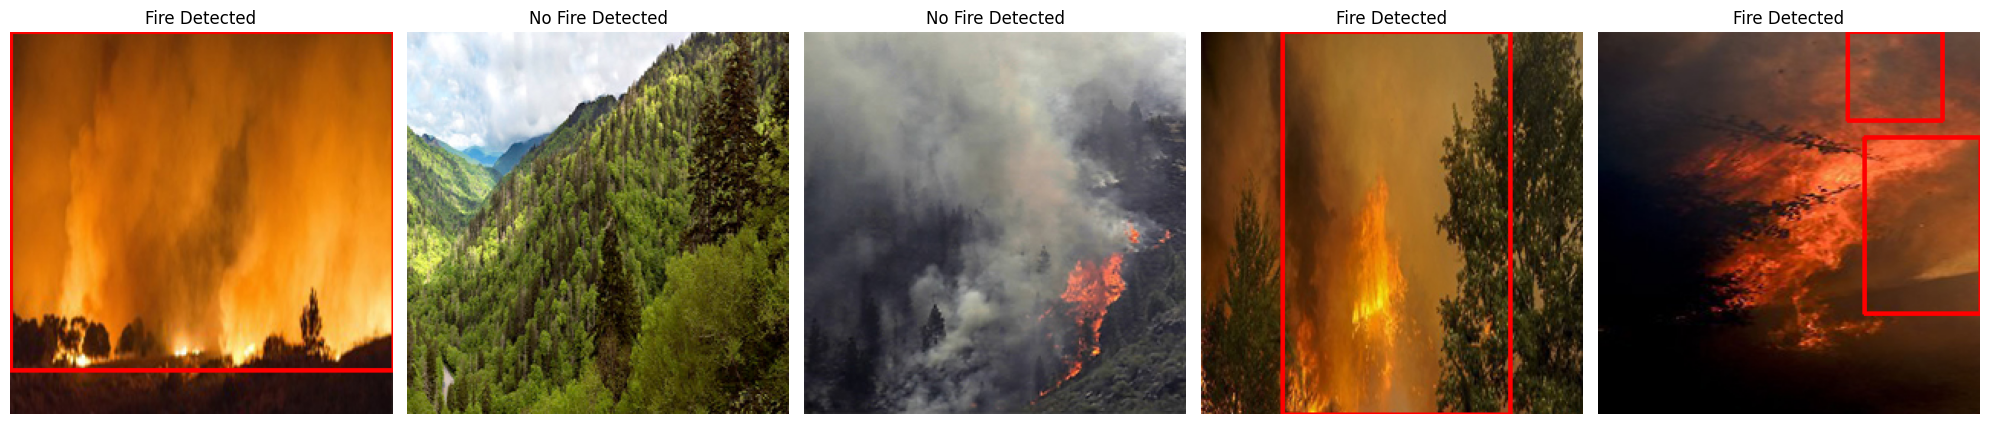

In [36]:
import matplotlib.pyplot as plt

# Predict fire on 5 random images from Testing Dataset'
# Get a list of image files in the testing directory
testing_images = [os.path.join('/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Testing', img) for img in os.listdir('/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Testing')]
# Select 5 random images
random_images = random.sample(testing_images, 5)

# Create a figure and axes for the subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # Adjust figsize as needed

# Iterate through random images and plot
for i, image_path in enumerate(random_images):
    output_image, feature_df = detect_forest_fire_and_extract_features(image_path)
    features = feature_df.values.flatten()

    features = np.pad(features, (0, X_train.shape[1] - len(features)), 'constant')
    features = scaler.transform([features])
    prediction = model.predict(features)
    result = "Fire Detected" if prediction == 1 else "No Fire Detected"

    # Display the result and the output image on the current subplot
    axes[i].imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
    axes[i].set_title(result)
    axes[i].axis('off')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [10]:
def detect_forest_fire_and_extract_features_plot(image_path):
    def contrast_stretching(image):
        min_val = np.min(image)
        max_val = np.max(image)
        stretched_image = ((image - min_val) / (max_val - min_val)) * 255
        return stretched_image.astype(np.uint8)

    def add_to_plot(image, step_name, images, titles):
        resized_image = cv2.resize(image, (512, 512))
        images.append(resized_image)
        titles.append(step_name)

    # Initialize lists for storing images and their titles
    images = []
    titles = []

    # Original image
    image = cv2.imread(image_path)
    add_to_plot(image, "01_Original_Image", images, titles)

    # Convert to HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    add_to_plot(hsv_image[:, :, 2], "02_HSV_V_Channel", images, titles)

    # Apply contrast stretching to the V channel
    hsv_image[:, :, 2] = contrast_stretching(hsv_image[:, :, 2])
    add_to_plot(hsv_image[:, :, 2], "03_Contrast_Stretched_V_Channel", images, titles)

    # Define HSV range for fire
    lower_fire = np.array([10, 100, 100])
    upper_fire = np.array([20, 255, 255])
    fire_mask = cv2.inRange(hsv_image, lower_fire, upper_fire)
    add_to_plot(fire_mask, "04_Fire_Mask_HSV_Thresholding", images, titles)

    # Otsu filtering
    v_channel = hsv_image[:, :, 2]
    _, otsu_thresholded = cv2.threshold(v_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    add_to_plot(otsu_thresholded, "05_Otsu_Thresholding", images, titles)

    # Combine fire mask with Otsu filter
    fire_mask = cv2.bitwise_and(fire_mask, otsu_thresholded)
    add_to_plot(fire_mask, "06_Combined_Fire_Mask", images, titles)

    # Edge detection
    sobel_x = cv2.Sobel(v_channel, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(v_channel, cv2.CV_64F, 0, 1, ksize=3)
    edges = cv2.magnitude(sobel_x, sobel_y).astype(np.uint8)
    add_to_plot(edges, "07_Edges", images, titles)

    # Combine edges with fire mask
    fire_mask = cv2.bitwise_and(fire_mask, edges)
    add_to_plot(fire_mask, "08_Refined_Fire_Mask_with_Edges", images, titles)

    # Morphological operations
    kernel = np.ones((5, 5), np.uint8)
    fire_mask = cv2.morphologyEx(fire_mask, cv2.MORPH_CLOSE, kernel)
    add_to_plot(fire_mask, "09_Morphological_Closing", images, titles)
    fire_mask = cv2.erode(fire_mask, kernel, iterations=1)
    add_to_plot(fire_mask, "10_Erosion", images, titles)

    # Contour detection
    contours, _ = cv2.findContours(fire_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_image = image.copy()
    cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)
    add_to_plot(contour_image, "11_Contours", images, titles)

    # Draw bounding boxes on detected fire regions
    output_image = image.copy()
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
    add_to_plot(output_image, "12_Bounding_Boxes", images, titles)

    # Plot all images in a 2x6 grid
    plt.figure(figsize=(16, 8))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(2, 6, i + 1)
        if len(img.shape) == 2:  # Grayscale image
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    return output_image

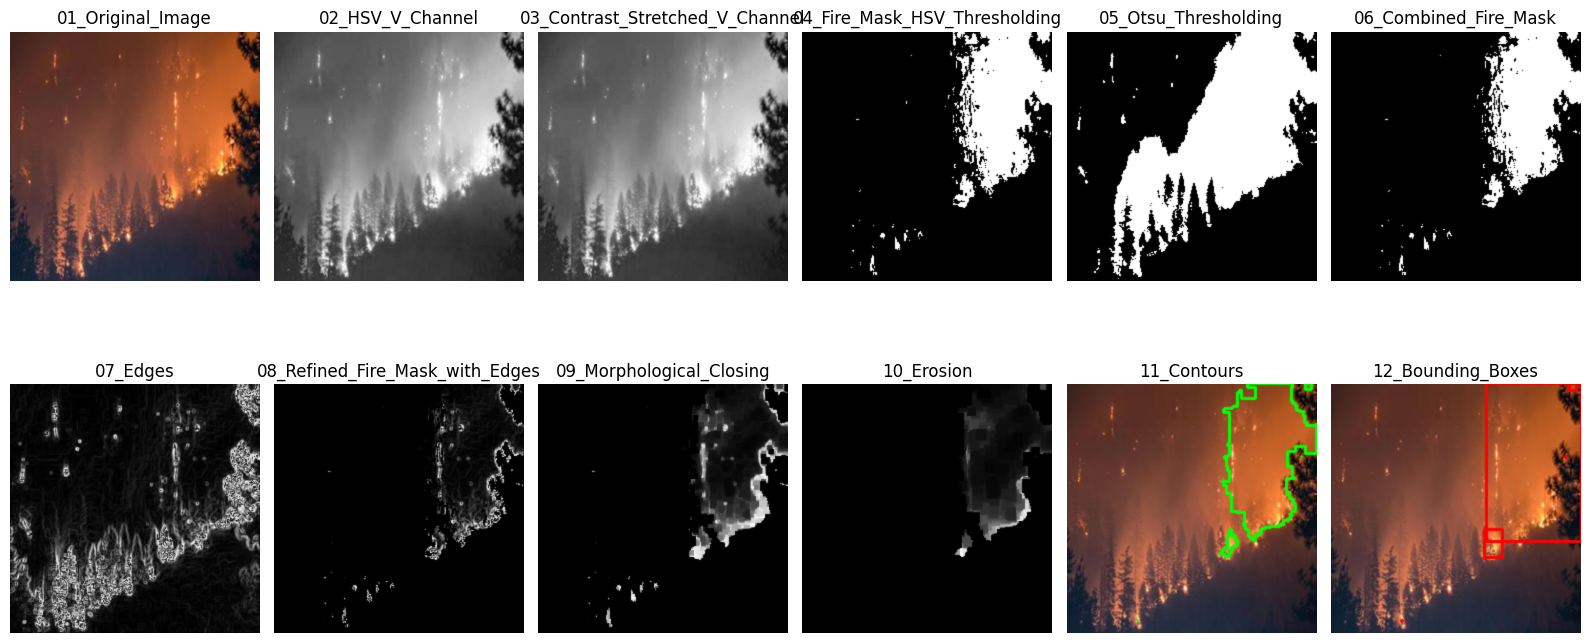

Fire Detected


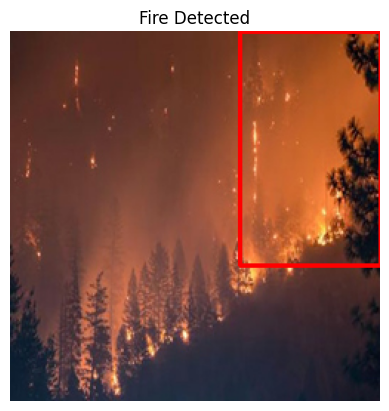

'Fire Detected'

In [38]:
# prompt: predict fire on a random image

import random

# Select a random image from the testing set
random_image_path = random.choice(testing_images)

# Predict fire on the random image
detect_forest_fire_and_extract_features_plot(random_image_path)
predict_fire(random_image_path)

In [27]:
ls '/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Testing'

fire_0002.jpg  fire_0426.jpg  fire_0670.jpg    nofire_0012.jpg  nofire_0354.jpg  nofire_0679.jpg
fire_0015.jpg  fire_0432.jpg  fire_0678.jpg    nofire_0032.jpg  nofire_0357.jpg  nofire_0686.jpg
fire_0027.jpg  fire_0436.jpg  fire_0680.jpg    nofire_0039.jpg  nofire_0365.jpg  nofire_0691.jpg
fire_0038.jpg  fire_0442.jpg  fire_0686.jpg    nofire_0051.jpg  nofire_0370.jpg  nofire_0696.jpg
fire_0040.jpg  fire_0444.jpg  fire_0691.jpg    nofire_0059.jpg  nofire_0372.jpg  nofire_0701.jpg
fire_0048.jpg  fire_0447.jpg  fire_0696.jpg    nofire_0076.jpg  nofire_0379.jpg  nofire_0708.jpg
fire_0063.jpg  fire_0449.jpg  fire_0698.jpg    nofire_0081.jpg  nofire_0389.jpg  nofire_0711.jpg
fire_0072.jpg  fire_0453.jpg  fire_0702.jpg    nofire_0084.jpg  nofire_0393.jpg  nofire_0714.jpg
fire_0084.jpg  fire_0456.jpg  fire_0706.jpg    nofire_0090.jpg  nofire_0400.jpg  nofire_0724.jpg
fire_0091.jpg  fire_0461.jpg  fire_0709.jpg    nofire_0094.jpg  nofire_0405.jpg  nofire_0729.jpg
fire_0097.jpg  fire_0466.jpg  

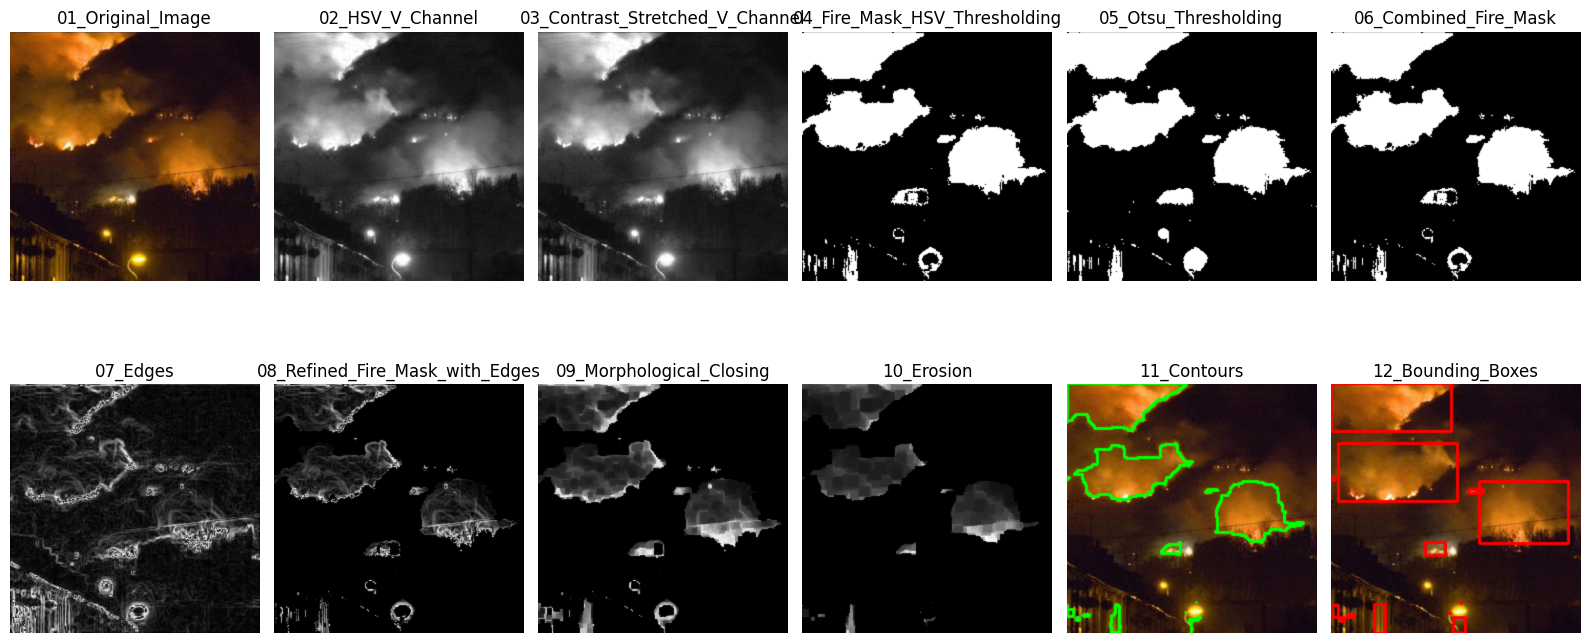

Fire Detected


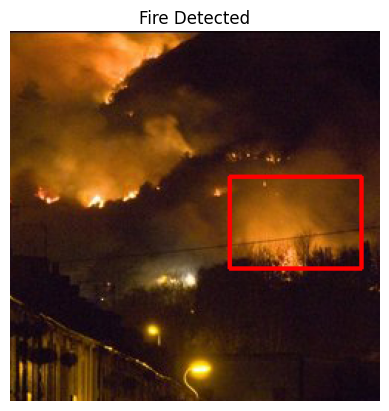

'Fire Detected'

In [39]:
# Select a random image from the testing set
image_path = '/root/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Testing/fire_0002.jpg'

# Predict fire on the random image
detect_forest_fire_and_extract_features_plot(image_path)
predict_fire(image_path)